# Lets start with a basic CNN for CIFAR10

In [ ]:
import torch

from torch import nn

from torchvision.transforms import v2

from torchvision import datasets

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

transform = v2.Compose(
    [v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


cuda


100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


In [ ]:
from torch.utils.data import DataLoader as Dataloader

bs = 4

trainloader = Dataloader(train_set, batch_size=bs, shuffle=True, num_workers=2)

testloader = Dataloader(test_set, batch_size=bs, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)
           )
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)
           )


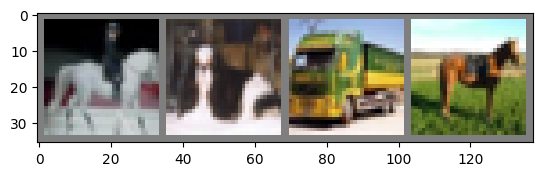

horse dog truck horse


In [ ]:

import torch.utils.data
import torchvision.utils as vutils
import numpy as np

print(train_set)

print(test_set)

def showImage(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))
  plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

showImage(vutils.make_grid(images))

print(' '.join(f'{classes[labels[j]]}' for j in range(bs)))

In [ ]:
import torch.nn as nn

import torch.nn.functional as F


# for pooling and unpooling pytorch provides return_indicies so that you don't have to manually implement switches
# pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
# output, indices = pool(input_tensor)



class convNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.feature_extractor = nn.Sequential(

      nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.ReLU(),
      nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.ReLU(),
      nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1, stride=1, padding=1),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.ReLU(),

    )

    n_channels = self.feature_extractor(torch.empty(1,3,32,32)).flatten(1).shape[1]

    self.classifier =  nn.Sequential(
      nn.Linear(in_features=n_channels, out_features=720),
      nn.ReLU(),
      nn.Linear(in_features=720, out_features=180),
      nn.ReLU(),
      nn.Linear(in_features=180, out_features=10)
    )
  def forward(self, x):
    features = self.feature_extractor(x)
    features = torch.flatten(features, 1)
    out = self.classifier(features)

    return out



In [ ]:
import torch.optim as optim

net = convNet().to(device)

print(net)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(net.parameters() , lr = 0.001, momentum = 0.9)

convNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=1600, out_features=720, bias=True)
    (1): ReLU()
    (2): Linear(in_features=720, out_features=180, bias=True)
    (3): ReLU()
    (4): Linear(in_features=180, out_features=10, bias=True)
  )
)


In [ ]:
epochs = 5

for epoch in range(epochs):
  running_trainLoss = 0.0
  for i, data in enumerate(trainloader, 0):
      inputs , target = data[0].to(device), data[1].to(device)

      optimizer.zero_grad()
      outputs = net(inputs)

      loss = criterion(input=outputs, target=target)
      loss.backward()
      optimizer.step()

      running_trainLoss += loss.item()
      if i % 2000 == 1999:
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_trainLoss / 2000:.3f}')
        running_trainLoss = 0.0

print('Finished Training')

PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)




Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x786bb82c96c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x786bb82c96c0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
if w.is_alive():    
self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive(): 
    ^^ ^ ^  ^ ^^^^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ 
   File "/usr/lib/pyth

[1,  2000] loss: 2.295
[1,  4000] loss: 1.998
[1,  6000] loss: 1.744
[1,  8000] loss: 1.593
[1, 10000] loss: 1.485
[1, 12000] loss: 1.411
[2,  2000] loss: 1.314
[2,  4000] loss: 1.308
[2,  6000] loss: 1.220
[2,  8000] loss: 1.199
[2, 10000] loss: 1.164
[2, 12000] loss: 1.115
[3,  2000] loss: 1.031
[3,  4000] loss: 1.022
[3,  6000] loss: 1.021
[3,  8000] loss: 0.994
[3, 10000] loss: 0.964
[3, 12000] loss: 0.942
[4,  2000] loss: 0.843
[4,  4000] loss: 0.850
[4,  6000] loss: 0.839
[4,  8000] loss: 0.834
[4, 10000] loss: 0.832
[4, 12000] loss: 0.831
[5,  2000] loss: 0.702
[5,  4000] loss: 0.707
[5,  6000] loss: 0.730
[5,  8000] loss: 0.726
[5, 10000] loss: 0.715
[5, 12000] loss: 0.711
Finished Training


In [ ]:


correct = 0
total = 0
classes_dict = {
          # class : [correct, total]
           'plane': [0, 0],
           'car'  : [0, 0],
           'bird' : [0, 0],
           'cat'  : [0, 0],
           'deer' : [0, 0],
           'dog'  : [0, 0],
           'frog' : [0, 0],
           'horse': [0, 0],
           'ship' : [0, 0],
           'truck': [0, 0]
           }
with torch.no_grad():
  for data in testloader:
    x, y_true = data[0].to(device) , data[1].to(device)

    y_hat = net(x)

    _, y_pred = torch.max(y_hat, 1)

    total += y_true.size(0)
    correct += (y_true == y_pred).sum().item()
    for label, pred in zip(y_true, y_pred):
      y = label.item()
      y_h = pred.item()
      classes_dict[classes[y]][1] += 1
      if y == y_h:
        classes_dict[classes[y]][0] += 1


print(f'Accuracy of the network on test images: {100 * correct // total} %\n')

for c in classes_dict:
  print(f'Accuracy of class {c} : {100 * (classes_dict.get(c)[0] / classes_dict.get(c)[1])}% \n')


### We will now begin the process of defining the pooling and unpooling operations explained in https://cs.nyu.edu/~fergus/drafts/deconv_iccv_names.pdf



In [3]:

# 3d max - pooling operation as defined :
# P(z) = [p, s]
# p = max abs value over a kernel that moves with a stride
import torch


def maxPool3d(kernel=2, featuremap=None, stride=2):
  if featuremap is None:
      raise ValueError("No featuremap passed / uninitialized")

  if featuremap.shape[1] != featuremap.shape[2]:
      raise ValueError("feature map shape must be square")

  out_h = (featuremap.shape[1] - kernel) // stride + 1
  out_w = (featuremap.shape[2] - kernel) // stride + 1

  z_hat = torch.zeros((out_h, out_w))
  z_abs = torch.abs(featuremap)
  s = []

  for iterR in range(out_h):
      for iterC in range(out_w):
          location = [0, 0, 0]
          max_val = float("-inf")

          for row in range(kernel):
              for col in range(kernel):
                  for k in range(featuremap.shape[0]):
                      rowval = row + iterR * stride
                      colval = col + iterC * stride

                      if max_val < z_abs[k, rowval, colval]:
                          max_val = z_abs[k, rowval, colval]
                          z_hat[iterR, iterC] = featuremap[k, rowval, colval]
                          location = [k, rowval, colval]

          s.append(location)

  return (z_hat, s)


# iter = 0
# kernel 0,0 :(0,0,0) ,(1,0,0)
# kernel 0,1 : (0,0,1),  (1,0,1)
# kernel 1,0 :,(0,1,0),  (1,1,0)
# kernel 1,1 :, (1,1,1),(0,1,1)
# top left ^

#iter = 1
# kernel 0,0 :(0,0,2) ,(1,0,2)
# kernel 0,1 : (0,0,2),  (1,0,2)
# kernel 1,0 :,(0,1,0),  (1,1,0)
# kernel 1,1 :, (1,1,1),(0,1,1)

# top right ^



      #  k,row,col
shape = (3,19,19)
z = torch.rand(shape)
print(z)
print("\n\n")
p = maxPool3d(kernel=2, featuremap=z, stride=2)
print("max pool", p[0], "\n")
print("switches", p[1])

tensor([[[0.2182, 0.1576, 0.5154,  ..., 0.4711, 0.6503, 0.1291],
         [0.7933, 0.6383, 0.7939,  ..., 0.9953, 0.9793, 0.2883],
         [0.7010, 0.5144, 0.0459,  ..., 0.5255, 0.2768, 0.0412],
         ...,
         [0.2697, 0.1046, 0.4665,  ..., 0.3705, 0.3285, 0.8288],
         [0.0890, 0.5137, 0.1423,  ..., 0.9793, 0.7158, 0.4206],
         [0.3570, 0.9854, 0.1859,  ..., 0.7140, 0.0066, 0.6223]],

        [[0.2521, 0.6392, 0.0955,  ..., 0.4257, 0.4480, 0.4550],
         [0.2610, 0.9461, 0.1459,  ..., 0.3060, 0.0798, 0.4389],
         [0.7065, 0.5671, 0.0285,  ..., 0.0973, 0.0655, 0.1335],
         ...,
         [0.1429, 0.7835, 0.6756,  ..., 0.0886, 0.2291, 0.6243],
         [0.6800, 0.3113, 0.5049,  ..., 0.2210, 0.4414, 0.3588],
         [0.8744, 0.4110, 0.9007,  ..., 0.5955, 0.7186, 0.9148]],

        [[0.4354, 0.7623, 0.4366,  ..., 0.2942, 0.5323, 0.8889],
         [0.1430, 0.8114, 0.0159,  ..., 0.0617, 0.9887, 0.5348],
         [0.2696, 0.4458, 0.8701,  ..., 0.4605, 0.8140, 0.

In [4]:
#Unpooling as defined - z_hat = U_s p where p is the pooled map produced above pairwise


# print(shape)

# we want the output tensor to be the same shape as the original input but to populate only zeros outside of the location specificed by the switches

print(p)

def unpooling3d(shape: tuple[int, int, int], p: torch.Tensor | None , s: list[list[int, int, int]] ) -> torch.Tensor:
  z_hat = torch.zeros(shape)
  # print(z_hat)

  # print(p)

  # print("map : rows" , p.shape[0], "x cols", p.shape[1])
  # print(torch.flatten(p))
  if p.shape[0] * p.shape[1] != len(s):
    raise ValueError("dimensional mismatch between switches and pooled map")

  # print(s)

  for location, value in zip(s, torch.flatten(p)):
    # print(location)
    k, x , y = location[0], location[1] , location[2]
    # print(f'k : {k}, x: {x} , y: {y}, val: {value}')
    z_hat[k][x][y] = value
  return z_hat

unpooled = unpooling3d(shape, p[0], p[1])

print(unpooled)

(tensor([[0.9461, 0.9978, 0.9810, 0.9235, 0.8695, 0.9897, 0.9459, 0.9790, 0.9953],
        [0.7896, 0.9800, 0.9858, 0.8487, 0.9308, 0.9491, 0.9423, 0.9850, 0.8981],
        [0.9552, 0.9552, 0.8238, 0.9439, 0.8596, 0.8081, 0.9484, 0.8082, 0.9853],
        [0.8955, 0.9988, 0.9840, 0.7951, 0.9548, 0.9062, 0.9712, 0.9555, 0.9831],
        [0.8289, 0.9224, 0.9788, 0.9942, 0.9271, 0.9542, 0.9803, 0.8758, 0.9056],
        [0.9123, 0.9325, 0.8306, 0.9225, 0.9977, 0.9556, 0.9668, 0.8160, 0.8249],
        [0.9903, 0.9853, 0.9240, 0.9944, 0.8330, 0.9483, 0.9878, 0.9062, 0.7549],
        [0.9967, 0.8562, 0.8917, 0.9731, 0.9606, 0.8191, 0.7453, 0.8467, 0.9902],
        [0.8883, 0.9692, 0.9316, 0.9239, 0.9327, 0.9993, 0.9539, 0.9406, 0.9793]]), [[1, 1, 1], [2, 1, 3], [1, 1, 5], [2, 0, 6], [1, 1, 9], [2, 1, 10], [1, 1, 13], [2, 1, 14], [0, 1, 16], [2, 3, 0], [0, 3, 2], [2, 3, 4], [1, 3, 6], [2, 3, 9], [1, 3, 10], [1, 2, 12], [1, 2, 15], [2, 3, 17], [1, 5, 1], [1, 5, 2], [2, 5, 5], [2, 5, 6], [2, 5, 8

# I will now try to implement a model that aims to reconstruct the given target image at each layer - I will train in the CSC objective s.t. the model will be forced into a sparse feature map solution at each layer

cuda
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)
           )
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)
           )


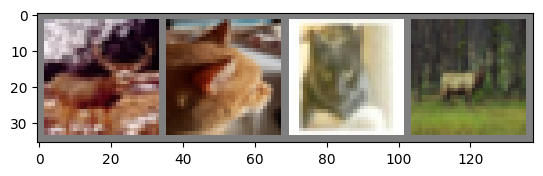

deer cat cat deer


In [7]:
import torch
from torch.utils.data import DataLoader as Dataloader
from torch import nn
from torchvision.transforms import v2
from torchvision import datasets
import matplotlib.pyplot as plt
import torch.utils.data
import torchvision.utils as vutils
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

transform = v2.Compose(
    [v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

bs = 4

trainloader = Dataloader(train_set, batch_size=bs, shuffle=True, num_workers=2)

testloader = Dataloader(test_set, batch_size=bs, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(train_set)

print(test_set)

def showImage(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))
  plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

showImage(vutils.make_grid(images))

print(' '.join(f'{classes[labels[j]]}' for j in range(bs)))



In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2, 2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 64, 1, 1, 0)

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            x = F.relu(self.conv1(dummy))
            x, _ = self.pool(x)
            x = F.relu(self.conv2(x))
            x, _ = self.pool(x)
            x = F.relu(self.conv3(x))
            n_channels = x.numel()

        self.fc1 = nn.Linear(n_channels, 720)
        self.fc2 = nn.Linear(720, 180)
        self.classifier = nn.Linear(180, 10)

    def forward(self, x, save_deconv=False):
        x = F.relu(self.conv1(x))
        if save_deconv:
            self.act1 = x.detach()
            self.size1 = x.size()      # [B, 16, 32, 32]

        x,idx1 = self.pool(x)

        x = F.relu(self.conv2(x))
        if save_deconv:
            self.idx1 = idx1
            self.act2 = x.detach()
            self.size2 = x.size()      # [B, 32, 16, 16]

        x, idx2 = self.pool(x)

        x = F.relu(self.conv3(x))
        if save_deconv:
            self.idx2 = idx2
            self.act3 = x.detach()     # [B, 64, 8, 8]

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.classifier(x)

    def deconv(self, k, layer):

        if layer == 1:
            z = torch.zeros_like(self.act1)
            z[:, k:k+1, :, :] = self.act1[:, k:k+1, :, :]

            z = F.relu(z)
            z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

        elif layer == 2:
            z = torch.zeros_like(self.act2)
            z[:, k:k+1, :, :] = self.act2[:, k:k+1, :, :]

            z = F.relu(z)
            z = F.conv_transpose2d(z, self.conv2.weight, padding=1)

            z = F.relu(z)
            z = self.unpool(z, self.idx1, output_size=self.size1)

            z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

        elif layer == 3:
            z = torch.zeros_like(self.act3)
            z[:, k:k+1, :, :] = self.act3[:, k:k+1, :, :]

            z = F.relu(z)

            # print("start:", z.shape)

            z = F.conv_transpose2d(z, self.conv3.weight)
            z = F.relu(z)
            # print("before unpool2:", z.shape, self.idx2.shape, self.size2)

            z = self.unpool(
                input=z,
                indices=self.idx2,
                output_size=self.size2
            )

            z = F.conv_transpose2d(z, self.conv2.weight, padding=1)
            z = F.relu(z)
            # print("before unpool1:", z.shape, self.idx1.shape, self.size1)

            z = self.unpool(
                input=z,
                indices=self.idx1,
                output_size=self.size1
            )

            z = F.conv_transpose2d(z, self.conv1.weight, padding=1)

        else:
            raise ValueError("Layer is invalid")

        return z

In [32]:
import torch.optim as optim



print(net)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(net.parameters() , lr = 0.001, momentum = 0.9)
epochs = 5

for epoch in range(epochs):
  running_trainLoss = 0.0
  for i, data in enumerate(trainloader, 0):
      inputs , target = data[0].to(device), data[1].to(device)

      optimizer.zero_grad()
      outputs = net(inputs)

      loss = criterion(input=outputs, target=target)
      loss.backward()
      optimizer.step()

      running_trainLoss += loss.item()
      if i % 2000 == 1999:
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_trainLoss / 2000:.3f}')
        running_trainLoss = 0.0

print('Finished Training')

PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)




ConvNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unpool): MaxUnpool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (fc1): Linear(in_features=4096, out_features=720, bias=True)
  (fc2): Linear(in_features=720, out_features=180, bias=True)
  (classifier): Linear(in_features=180, out_features=10, bias=True)
)
[1,  2000] loss: 2.209
[1,  4000] loss: 1.836
[1,  6000] loss: 1.603
[1,  8000] loss: 1.509
[1, 10000] loss: 1.417
[1, 12000] loss: 1.355
[2,  2000] loss: 1.246
[2,  4000] loss: 1.211
[2,  6000] loss: 1.160
[2,  8000] loss: 1.138
[2, 10000] loss: 1.072
[2, 12000] loss: 1.040
[3,  2000] loss: 0.935
[3,  4000] loss: 0.924
[3,  6000] loss: 0.908
[3,  8000] loss: 0.914
[3, 10000] loss: 0.872
[3, 12000] loss: 0.871
[4,  200

In [33]:


correct = 0
total = 0
classes_dict = {
          # class : [correct, total]
           'plane': [0, 0],
           'car'  : [0, 0],
           'bird' : [0, 0],
           'cat'  : [0, 0],
           'deer' : [0, 0],
           'dog'  : [0, 0],
           'frog' : [0, 0],
           'horse': [0, 0],
           'ship' : [0, 0],
           'truck': [0, 0]
           }
with torch.no_grad():
  for data in testloader:
    x, y_true = data[0].to(device) , data[1].to(device)

    y_hat = net(x)

    _, y_pred = torch.max(y_hat, 1)

    total += y_true.size(0)
    correct += (y_true == y_pred).sum().item()
    for label, pred in zip(y_true, y_pred):
      y = label.item()
      y_h = pred.item()
      classes_dict[classes[y]][1] += 1
      if y == y_h:
        classes_dict[classes[y]][0] += 1


print(f'Accuracy of the network on test images: {100 * correct // total} %\n')

for c in classes_dict:
  print(f'Accuracy of class {c} : {100 * (classes_dict.get(c)[0] / classes_dict.get(c)[1])}% \n')



Accuracy of the network on test images: 70 %

Accuracy of class plane : 75.3% 

Accuracy of class car : 80.7% 

Accuracy of class bird : 58.599999999999994% 

Accuracy of class cat : 60.6% 

Accuracy of class deer : 58.3% 

Accuracy of class dog : 58.3% 

Accuracy of class frog : 85.3% 

Accuracy of class horse : 74.2% 

Accuracy of class ship : 84.2% 

Accuracy of class truck : 73.5% 



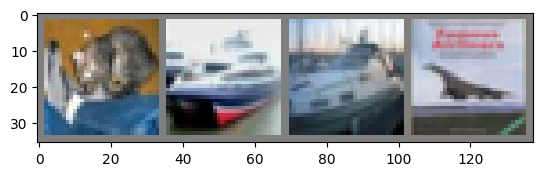

cat ship ship plane
layer 1 representations:


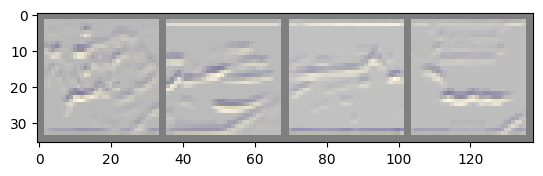

layer 2 representations:


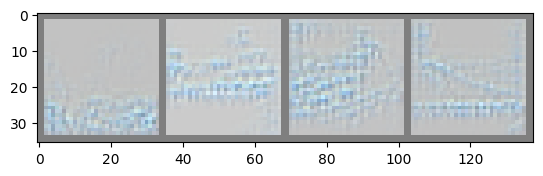

layer 3 representations:


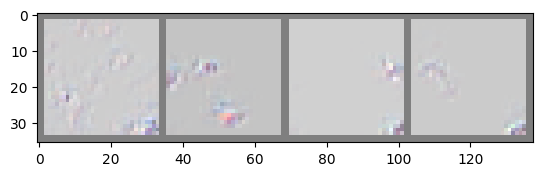

In [68]:
def showImage(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1,2,0)))
  plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)
# image = images[0].to(device).unsqueeze(0)

showImage(vutils.make_grid(images))
print(' '.join(f'{classes[labels[j]]}' for j in range(bs)))
net = ConvNet().to(device)
net.load_state_dict(
    torch.load(PATH, map_location=device)
)

net.eval()
# import inspect
# print(inspect.getsource(net.deconv))
featureVis3 = []
featureVis2 = []
featureVis1 = []
with torch.no_grad():
  for image in images:
    image = image.to(device).unsqueeze(0)
    logits = net(image, save_deconv=True)
    # print("act1", net.act1.shape, "idx1", net.idx1.shape, "size1", net.size1)
    # print("act2", net.act2.shape, "idx2", net.idx2.shape, "size2", net.size2)
    # print("act3", net.act3.shape)
    recon = net.deconv(k=10, layer=3)
    recon_cpu = recon.squeeze(0).cpu()
    recon_cpu = recon_cpu - recon_cpu.min()
    recon_cpu = recon_cpu / (recon_cpu.max() + 1e-8)
    featureVis3.append(recon_cpu)

    recon = net.deconv(k=10, layer=2)
    recon_cpu = recon.squeeze(0).cpu()
    recon_cpu = recon_cpu - recon_cpu.min()
    recon_cpu = recon_cpu / (recon_cpu.max() + 1e-8)
    featureVis2.append(recon_cpu)

    recon = net.deconv(k=10, layer=1)

    recon_cpu = recon.squeeze(0).cpu()
    recon_cpu = recon_cpu - recon_cpu.min()
    recon_cpu = recon_cpu / (recon_cpu.max() + 1e-8)
    featureVis1.append(recon_cpu)

print("layer 1 representations:")
showImage(vutils.make_grid(featureVis1))
print("layer 2 representations:")
showImage(vutils.make_grid(featureVis2))
print("layer 3 representations:")
showImage(vutils.make_grid(featureVis3))
